# AI-Based Ransomware Attack Path Simulation System

## Artificial Intelligence (CSC-262)

### COMSATS University Islamabad
### CUI Abbottabad Campus

#### Submitted By:
 Ahmed gul -- Fa24-bcs-114 

#### Instructor:
Zeenat Zulfiqar

---

## Project Objective

This project simulates ransomware attack path discovery in a computer network using Artificial Intelligence search algorithms.

The system implements:

- BFS
- DFS
- UCS
- A*
- Hill Climbing
- Minimax
- Alpha-Beta Pruning

The network is modeled as a weighted graph where:
- Nodes represent systems
- Edges represent network connections
- Weights represent vulnerabilities or attack costs

In [84]:
# ============================================
# INSTALL REQUIRED LIBRARIES
# ============================================

!pip install networkx matplotlib

# Introduction

Cyber attackers often move through multiple systems before reaching a critical target server.

This project uses AI search algorithms to simulate ransomware attack paths inside a network.

The goal is to compare the performance of different search algorithms in cybersecurity environments.

In [85]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq
import time

# Network Graph Construction

The network contains:

- Employee PCs
- Firewall
- Email Server
- Backup Server
- Database Server

Edge weights represent attack difficulty and vulnerability levels.

In [86]:
# ============================================
# CREATE NETWORK GRAPH
# ============================================

graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 3, 'E': 5},
    'C': {'F': 2, 'I': 6},
    'D': {'G': 4},
    'E': {'G': 2, 'H': 7},
    'F': {'H': 3},
    'G': {'J': 5},
    'H': {'J': 2},
    'I': {'J': 4},
    'J': {}
}

# Start and Goal Nodes
start_node = 'A'
goal_node = 'J'

print("Start Node:", start_node)
print("Goal Node:", goal_node)

Start Node: A
Goal Node: J


# Network Visualization

The following graph represents the ransomware attack environment.

Red highlighted edges later represent the discovered attack path.

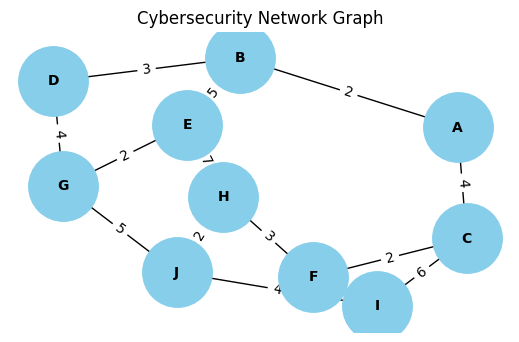

In [87]:
# ============================================
# VISUALIZE NETWORK GRAPH
# ============================================

G = nx.Graph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(5,3))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color='skyblue',
    font_size=10,
    font_weight='bold'
)

labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

plt.title("Cybersecurity Network Graph")
plt.show()

# Heuristic Function for A*

A* uses heuristic values to estimate how close a node is to the target server.

Lower heuristic values indicate closer distance to the goal node.

In [88]:
# ============================================
# HEURISTIC VALUES
# ============================================

heuristic = {
    'A': 10,
    'B': 8,
    'C': 7,
    'D': 6,
    'E': 5,
    'F': 4,
    'G': 3,
    'H': 2,
    'I': 2,
    'J': 0
}

print("Heuristic Values Loaded Successfully")

Heuristic Values Loaded Successfully


In [89]:
# ============================================
# PATH COST CALCULATION FUNCTION
# ============================================

def calculate_cost(path):

    total = 0

    for i in range(len(path)-1):
        total += graph[path[i]][path[i+1]]

    return total

# Breadth First Search (BFS)

BFS explores the graph level-by-level.

It guarantees the shortest path in terms of number of edges.

In [90]:
# ============================================
# BREADTH FIRST SEARCH (BFS)
# ============================================

def bfs(graph, start, goal):

    start_time = time.time()

    queue = deque([[start]])

    visited = set()

    expanded = 0

    while queue:

        path = queue.popleft()

        node = path[-1]

        if node == goal:

            end_time = time.time()

            return {
                'Path': path,
                'Cost': calculate_cost(path),
                'Expanded': expanded,
                'Time': (end_time - start_time) * 1000
            }

        if node not in visited:

            visited.add(node)

            expanded += 1

            for neighbor in graph[node]:

                new_path = list(path)

                new_path.append(neighbor)

                queue.append(new_path)

# Run BFS
bfs_result = bfs(graph, start_node, goal_node)

print(bfs_result)

{'Path': ['A', 'C', 'I', 'J'], 'Cost': 14, 'Expanded': 9, 'Time': 0.021696090698242188}


# Depth First Search (DFS)

Depth First Search explores the graph deeply before backtracking.

It follows one branch completely before moving toward another branch.

In [91]:
# ============================================
# DEPTH FIRST SEARCH (DFS)
# ============================================

def dfs(graph, start, goal):

    # Start execution timer
    start_time = time.time()

    # Stack for DFS
    stack = [[start]]

    # Visited nodes
    visited = set()

    # Count expanded nodes
    expanded = 0

    while stack:

        # Remove last path from stack
        path = stack.pop()

        # Current node
        node = path[-1]

        # Goal check
        if node == goal:

            end_time = time.time()

            return {
                'Path': path,
                'Cost': calculate_cost(path),
                'Expanded': expanded,
                'Time': (end_time - start_time) * 1000
            }

        # Visit node
        if node not in visited:

            visited.add(node)

            expanded += 1

            # Explore neighbors
            for neighbor in graph[node]:

                new_path = list(path)

                new_path.append(neighbor)

                stack.append(new_path)

# Run DFS
dfs_result = dfs(graph, start_node, goal_node)

# Display DFS Results
print("\n========== DFS RESULT ==========")

print("Path:", " -> ".join(dfs_result['Path']))

print("Total Cost:", dfs_result['Cost'])

print("Nodes Expanded:", dfs_result['Expanded'])

print(f"Execution Time: {dfs_result['Time']:.4f} ms")


========== DFS RESULT ==========
Path: A -> C -> I -> J
Total Cost: 14
Nodes Expanded: 3
Execution Time: 0.0117 ms


# Uniform Cost Search (UCS)

Uniform Cost Search expands the lowest-cost path first.

It guarantees the optimal minimum-cost solution.

In [92]:
# ============================================
# UNIFORM COST SEARCH (UCS)
# ============================================

def ucs(graph, start, goal):

    # Start execution timer
    start_time = time.time()

    # Priority queue
    priority_queue = [(0, [start])]

    # Visited nodes
    visited = set()

    # Expanded nodes count
    expanded = 0

    while priority_queue:

        # Get minimum cost path
        cost, path = heapq.heappop(priority_queue)

        # Current node
        node = path[-1]

        # Goal check
        if node == goal:

            end_time = time.time()

            return {
                'Path': path,
                'Cost': cost,
                'Expanded': expanded,
                'Time': (end_time - start_time) * 1000
            }

        # Visit node
        if node not in visited:

            visited.add(node)

            expanded += 1

            # Explore neighbors
            for neighbor, weight in graph[node].items():

                new_cost = cost + weight

                new_path = path + [neighbor]

                heapq.heappush(
                    priority_queue,
                    (new_cost, new_path)
                )

# Run UCS
ucs_result = ucs(graph, start_node, goal_node)

# Display UCS Results
print("\n========== UCS RESULT ==========")

print("Path:", " -> ".join(ucs_result['Path']))

print("Total Cost:", ucs_result['Cost'])

print("Nodes Expanded:", ucs_result['Expanded'])

print(f"Execution Time: {ucs_result['Time']:.4f} ms")


========== UCS RESULT ==========
Path: A -> C -> F -> H -> J
Total Cost: 11
Nodes Expanded: 9
Execution Time: 0.0246 ms


# A* Search Algorithm

A* combines actual path cost and heuristic estimation.

It efficiently finds the optimal path toward the target node.

In [93]:
# ============================================
# A* SEARCH ALGORITHM
# ============================================

def astar(graph, start, goal, heuristic):

    # Start execution timer
    start_time = time.time()

    # Priority queue
    pq = [(heuristic[start], 0, [start])]

    # Visited nodes
    visited = set()

    # Expanded nodes
    expanded = 0

    while pq:

        # Get lowest f(n)
        f_cost, g_cost, path = heapq.heappop(pq)

        # Current node
        node = path[-1]

        # Goal check
        if node == goal:

            end_time = time.time()

            return {
                'Path': path,
                'Cost': g_cost,
                'Expanded': expanded,
                'Time': (end_time - start_time) * 1000
            }

        # Visit node
        if node not in visited:

            visited.add(node)

            expanded += 1

            # Explore neighbors
            for neighbor, weight in graph[node].items():

                # Actual cost
                new_g = g_cost + weight

                # Total estimated cost
                new_f = new_g + heuristic[neighbor]

                # New path
                new_path = path + [neighbor]

                heapq.heappush(
                    pq,
                    (new_f, new_g, new_path)
                )

# Run A*
astar_result = astar(
    graph,
    start_node,
    goal_node,
    heuristic
)

# Display A* Results
print("\n========== A* RESULT ==========")

print("Path:", " -> ".join(astar_result['Path']))

print("Total Cost:", astar_result['Cost'])

print("Nodes Expanded:", astar_result['Expanded'])

print(f"Execution Time: {astar_result['Time']:.4f} ms")


========== A* RESULT ==========
Path: A -> C -> F -> H -> J
Total Cost: 11
Nodes Expanded: 6
Execution Time: 0.0200 ms


# Hill Climbing Algorithm

Hill Climbing selects the best local neighbor using heuristic values.

It may fail if the algorithm becomes trapped in a local maximum.

In [94]:
# ============================================
# HILL CLIMBING ALGORITHM
# ============================================

def hill_climbing(graph, start, goal, heuristic):

    # Start execution timer
    start_time = time.time()

    # Current node
    current = start

    # Path storage
    path = [current]

    # Expanded nodes
    expanded = 0

    while current != goal:

        expanded += 1

        neighbors = graph[current]

        # Stop if no neighbors
        if not neighbors:
            break

        # Select best heuristic neighbor
        next_node = min(
            neighbors,
            key=lambda x: heuristic[x]
        )

        # Local maxima condition
        if heuristic[next_node] >= heuristic[current]:

            print("Local Maximum Reached!")

            break

        # Move to next node
        path.append(next_node)

        current = next_node

    end_time = time.time()

    return {
        'Path': path,
        'Cost': calculate_cost(path),
        'Expanded': expanded,
        'Time': (end_time - start_time) * 1000
    }

# Run Hill Climbing
hill_result = hill_climbing(
    graph,
    start_node,
    goal_node,
    heuristic
)

# Display Results
print("\n========== HILL CLIMBING RESULT ==========")

print("Path:", " -> ".join(hill_result['Path']))

print("Total Cost:", hill_result['Cost'])

print("Nodes Expanded:", hill_result['Expanded'])

print(f"Execution Time: {hill_result['Time']:.4f} ms")


========== HILL CLIMBING RESULT ==========
Path: A -> C -> I -> J
Total Cost: 14
Nodes Expanded: 3
Execution Time: 0.0145 ms


# Minimax Algorithm

Minimax simulates attacker vs defender decision-making.

The attacker tries to maximize attack success while the defender minimizes it.

In [95]:
# ============================================
# MINIMAX ALGORITHM
# ============================================

def minimax(depth, node_index, maximizing_player, values):

    # Leaf node condition
    if depth == 3:
        return values[node_index]

    # Maximizer
    if maximizing_player:

        return max(

            minimax(
                depth + 1,
                node_index * 2,
                False,
                values
            ),

            minimax(
                depth + 1,
                node_index * 2 + 1,
                False,
                values
            )
        )

    # Minimizer
    else:

        return min(

            minimax(
                depth + 1,
                node_index * 2,
                True,
                values
            ),

            minimax(
                depth + 1,
                node_index * 2 + 1,
                True,
                values
            )
        )

# Sample utility values
values = [3, 5, 6, 9, 1, 2, 0, -1]

# Run Minimax
minimax_result = minimax(
    0,
    0,
    True,
    values
)

# Display Result
print("\n========== MINIMAX RESULT ==========")

print("Optimal Value:", minimax_result)


========== MINIMAX RESULT ==========
Optimal Value: 5


# Alpha-Beta Pruning

Alpha-Beta Pruning improves Minimax performance by removing unnecessary branches.

This reduces computation time significantly.

In [96]:
# ============================================
# ALPHA-BETA PRUNING
# ============================================

def alphabeta(
    depth,
    node_index,
    maximizing_player,
    values,
    alpha,
    beta
):

    # Leaf node
    if depth == 3:
        return values[node_index]

    # Maximizer
    if maximizing_player:

        best = -1000

        for i in range(2):

            value = alphabeta(
                depth + 1,
                node_index * 2 + i,
                False,
                values,
                alpha,
                beta
            )

            best = max(best, value)

            alpha = max(alpha, best)

            # Pruning condition
            if beta <= alpha:
                break

        return best

    # Minimizer
    else:

        best = 1000

        for i in range(2):

            value = alphabeta(
                depth + 1,
                node_index * 2 + i,
                True,
                values,
                alpha,
                beta
            )

            best = min(best, value)

            beta = min(beta, best)

            # Pruning condition
            if beta <= alpha:
                break

        return best

# Run Alpha-Beta Pruning
alphabeta_result = alphabeta(
    0,
    0,
    True,
    values,
    -1000,
    1000
)

# Display Result
print("\n========== ALPHA-BETA RESULT ==========")

print("Optimal Value:", alphabeta_result)


========== ALPHA-BETA RESULT ==========
Optimal Value: 5


# Comparative Analysis

The following table compares all implemented algorithms based on:

- Path discovered
- Total cost
- Nodes expanded
- Execution time

In [97]:
# ============================================
# COMPARISON RESULTS
# ============================================

results = {
    'BFS': bfs_result,
    'DFS': dfs_result,
    'UCS': ucs_result,
    'A*': astar_result,
    'Hill Climbing': hill_result
}

print("\n========== FINAL COMPARISON ==========\n")

for algo, result in results.items():

    print("Algorithm:", algo)

    print("Path:", " -> ".join(result['Path']))

    print("Cost:", result['Cost'])

    print("Nodes Expanded:", result['Expanded'])

    print(f"Execution Time: {result['Time']:.4f} ms")

    print("----------------------------------")


========== FINAL COMPARISON ==========

Algorithm: BFS
Path: A -> C -> I -> J
Cost: 14
Nodes Expanded: 9
Execution Time: 0.0217 ms
----------------------------------
Algorithm: DFS
Path: A -> C -> I -> J
Cost: 14
Nodes Expanded: 3
Execution Time: 0.0117 ms
----------------------------------
Algorithm: UCS
Path: A -> C -> F -> H -> J
Cost: 11
Nodes Expanded: 9
Execution Time: 0.0246 ms
----------------------------------
Algorithm: A*
Path: A -> C -> F -> H -> J
Cost: 11
Nodes Expanded: 6
Execution Time: 0.0200 ms
----------------------------------
Algorithm: Hill Climbing
Path: A -> C -> I -> J
Cost: 14
Nodes Expanded: 3
Execution Time: 0.0145 ms
----------------------------------


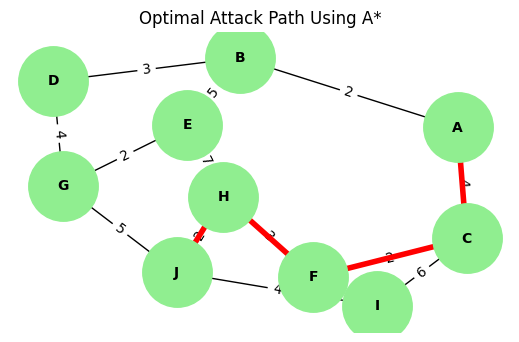

In [98]:
# ============================================
# FINAL PATH VISUALIZATION
# ============================================

plt.figure(figsize=(5,3))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color='lightgreen',
    font_size=10,
    font_weight='bold'
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

# Highlight A* Path
path_edges = list(zip(
    astar_result['Path'],
    astar_result['Path'][1:]
))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color='red',
    width=4
)

plt.title("Optimal Attack Path Using A*")

plt.show()

In [99]:
# ============================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================
# ipywidgets -> interactive UI elements (dropdown, button)
# display, clear_output -> output show & refresh screen

import ipywidgets as widgets
from IPython.display import display, clear_output

In [100]:
# ============================================
# STEP 2: ALGORITHM SELECTION DROPDOWN
# ============================================
# This allows user to select which AI algorithm to run
# Options include BFS, DFS, UCS, A*, and Hill Climbing

algo_dropdown = widgets.Dropdown(
    options=['BFS', 'DFS', 'UCS', 'A*', 'Hill Climbing'],
    value='BFS',
    description='Algorithm:'
)

display(algo_dropdown)

Dropdown(description='Algorithm:', options=('BFS', 'DFS', 'UCS', 'A*', 'Hill Climbing'), value='BFS')

In [101]:
# ============================================
# STEP 3: START AND GOAL NODE SELECTION
# ============================================
# User selects starting point and target node
# These values are used in graph search algorithms

start_dropdown = widgets.Dropdown(
    options=list(graph.keys()),
    description='Start:'
)

goal_dropdown = widgets.Dropdown(
    options=list(graph.keys()),
    description='Goal:'
)

display(start_dropdown, goal_dropdown)

Dropdown(description='Start:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'), value='A')

Dropdown(description='Goal:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'), value='A')

In [102]:
# ============================================
# STEP 4: RUN SIMULATION BUTTON
# ============================================
# When clicked, it executes selected algorithm
# and displays the result dynamically

button = widgets.Button(
    description="Run Simulation",
    button_style='success'
)

display(button)

Button(button_style='success', description='Run Simulation', style=ButtonStyle())

In [103]:
# ============================================
# STEP 5: EXECUTE SELECTED ALGORITHM
# ============================================
# This function connects UI with backend algorithms
# It runs selected algorithm and shows results

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()

        # Get user selections
        algo = algo_dropdown.value
        start = start_dropdown.value
        goal = goal_dropdown.value

        print("Selected Algorithm:", algo)
        print("Start Node:", start)
        print("Goal Node:", goal)

        # Run selected algorithm
        if algo == "BFS":
            result = bfs(graph, start, goal)

        elif algo == "DFS":
            result = dfs(graph, start, goal)

        elif algo == "UCS":
            result = ucs(graph, start, goal)

        elif algo == "A*":
            result = astar(graph, start, goal, heuristic)

        elif algo == "Hill Climbing":
            result = hill_climbing(graph, start, goal, heuristic)

        # Display results
        print("\n========== RESULT ==========")
        print("Path:", result['Path'])
        print("Total Cost:", result['Cost'])
        print("Nodes Expanded:", result['Expanded'])
        print("Execution Time:", result['Time'], "ms")

button.on_click(on_button_click)

display(output)

Output()

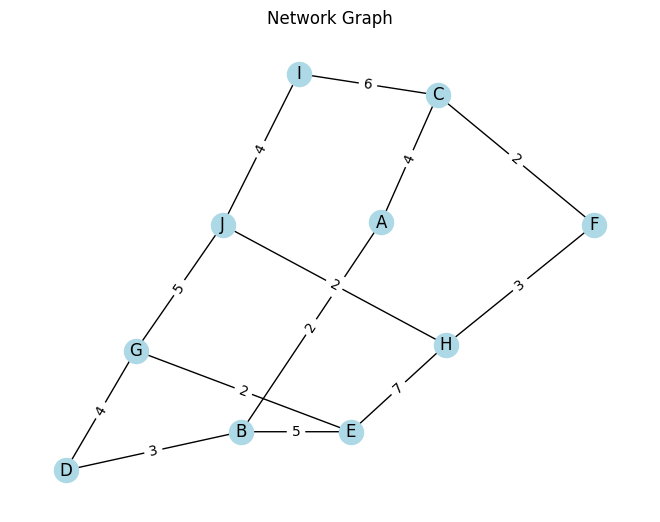

In [104]:
# ============================================
# STEP 6: GRAPH VISUALIZATION
# ============================================
# This shows network graph structure using NetworkX
# Nodes = systems, Edges = connections, Weights = risk

import networkx as nx
import matplotlib.pyplot as plt

def draw_graph():
    G = nx.Graph()

    # Add edges with weights
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)

    # Draw graph nodes and edges
    nx.draw(G, pos, with_labels=True, node_color='lightblue')

    # Show edge weights
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title("Network Graph")
    plt.show()

draw_graph()

Conclusion:
This project successfully demonstrates an AI-based ransomware attack path simulation using different search algorithms. Among all, A* performed best in finding the optimal path efficiently. The system helps in understanding how AI techniques can be applied in cybersecurity for analyzing attack paths.